# AMTTrack v9 — Velocity Guard Fix

Builds on v8 (burst-gated Kalman). One additional fix:
- **Velocity corruption guard**: Kalman only updates from frames where `pred_score >= SCORE_THRESHOLD (0.7)`.
  Previously, a failed re-acquisition after a long burst would feed a garbage position into Kalman,
  corrupting the velocity estimate for all subsequent predictions.

All v8 changes retained:
- Kalman activates immediately on high DVS activity, runs for entire burst (no cap)
- Search widens after KALMAN_MAX_BLIND burst frames to aid re-acquisition
- pred_score=0.0 returned on burst frames (belt-and-suspenders THOR guard)

**Sections**
1. Prerequisites
2. Experiment config
3. Run tracking
4. Metrics (vs baseline)
5. Burst analysis
6. Per-sequence signal plots
7. Visualisation

## Prerequisites

In [1]:
%%capture
!git clone https://github.com/pofce/ATM.git FELT_SOT_Benchmark
%cd /content/FELT_SOT_Benchmark/AMTTrack_v2/

In [2]:
%%capture
!pip install jpeg4py lmdb visdom

In [3]:
import os, shutil, re
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%%capture
!python tracking/create_default_local_file.py --workspace_dir . --data_dir ./data --save_dir ./output

In [5]:
%%bash
set -e
SRC=/content/drive/MyDrive/Diploma_project/Datasets/AMTTrack/v2
mkdir -p pretrained_networks output/checkpoints/train/amttrack/fe108
cp "$SRC/pretrained_networks/OSTrack_ep0300.pth.tar" pretrained_networks/
cp "$SRC/AMTTrack_ep0098.pth.tar" output/checkpoints/train/amttrack/fe108/AMTTrack_ep0050.pth.tar

## Experiment Config

In [ ]:
# ── change these ───────────────────────────────────────────────────────────────
DATASET = 'fe108'

FLICKER_SEQUENCES = ['ball_1hz', 'ball_2hz', 'ball_4hz', 'ball_8hz', 'banana_1hz', 'banana_2hz']
CONTROL_SEQUENCES = ['airplane_mul222', 'bike333', 'tower']
SEQUENCES         = FLICKER_SEQUENCES + CONTROL_SEQUENCES

FLICKER_DATA_ROOT = '/content/drive/MyDrive/Diploma_project/Datasets/Illumination_custom/seya/flicker'
CONTROL_DATA_ROOT = '/content/drive/MyDrive/Diploma_project/Datasets/FE108(v2)/test'
SEQ_DATA_ROOT     = {s: FLICKER_DATA_ROOT for s in FLICKER_SEQUENCES}
SEQ_DATA_ROOT.update({s: CONTROL_DATA_ROOT for s in CONTROL_SEQUENCES})

USE_MOTION_MODEL   = True
ADAPTIVE_MODALITY  = False
DISP_EMA_ALPHA     = 0.1

DVS_BG_LEVEL        = 255.0
DVS_BURST_THRESHOLD = 150.0
KALMAN_MIN_BLIND    = 2   # consecutive burst frames before Kalman activates
KALMAN_MAX_BLIND    = 20  # search widens after this many burst frames

# Baselines — no motion model
BASELINE_NO_KALMAN = {
    'ball_1hz':        1.0000,
    'ball_2hz':        0.4118,
    'ball_4hz':        0.0187,
    'ball_8hz':        0.1015,
    'banana_1hz':      0.9071,
    'banana_2hz':      0.7934,
    'airplane_mul222': 0.6802,
    'bike333':         0.5362,
    'tower':           0.9921,
}

BASE        = '/content/FELT_SOT_Benchmark/AMTTrack_v2'
LOCAL_DATA  = f'{BASE}/data/FE108/test'
RESULTS_DIR = f'{BASE}/output/test/tracking_results/amttrack/{DATASET}'
YAML_PATH   = f'{BASE}/experiments/amttrack/{DATASET}.yaml'

print(f'Sequences       : {SEQUENCES}')
print(f'MOTION_MODEL    : {USE_MOTION_MODEL}')
print(f'BURST_THRESHOLD : {DVS_BURST_THRESHOLD}')
print(f'KALMAN_MIN_BLIND: {KALMAN_MIN_BLIND}')
print(f'KALMAN_MAX_BLIND: {KALMAN_MAX_BLIND}')
print(f'RESULTS_DIR     : {RESULTS_DIR}')

In [7]:
# Copy sequences from Drive
for seq in tqdm(SEQUENCES, desc='Copying'):
    dst = os.path.join(LOCAL_DATA, seq)
    os.makedirs(dst, exist_ok=True)
    src = os.path.join(SEQ_DATA_ROOT[seq], seq)
    for sub in ('aps', 'dvs'):
        shutil.copytree(os.path.join(src, sub), os.path.join(dst, sub), dirs_exist_ok=True)
    shutil.copy2(os.path.join(src, 'groundtruth_rect.txt'), os.path.join(dst, 'groundtruth_rect.txt'))
print('Done.')

Copying:   0%|          | 0/6 [00:00<?, ?it/s]

Done.


In [ ]:
# Patch yaml
_yaml = open(YAML_PATH).read()
for key, val in [
    ('MOTION_MODEL',        USE_MOTION_MODEL),
    ('ADAPTIVE_MODALITY',   ADAPTIVE_MODALITY),
    ('DISP_EMA_ALPHA',      DISP_EMA_ALPHA),
    ('DVS_BG_LEVEL',        DVS_BG_LEVEL),
    ('DVS_BURST_THRESHOLD', DVS_BURST_THRESHOLD),
    ('KALMAN_MIN_BLIND',    KALMAN_MIN_BLIND),
    ('KALMAN_MAX_BLIND',    KALMAN_MAX_BLIND),
]:
    _yaml = re.sub(rf'({key}\s*:\s*)\S+', rf'\g<1>{val}', _yaml)
open(YAML_PATH, 'w').write(_yaml)
print(f'MOTION_MODEL        = {USE_MOTION_MODEL}')
print(f'DVS_BURST_THRESHOLD = {DVS_BURST_THRESHOLD}')
print(f'KALMAN_MIN_BLIND    = {KALMAN_MIN_BLIND}')
print(f'KALMAN_MAX_BLIND    = {KALMAN_MAX_BLIND}')
print(f'Written → {YAML_PATH}')

In [9]:
# Write list.txt
seq_dirs = sorted([d for d in os.listdir(LOCAL_DATA) if os.path.isdir(os.path.join(LOCAL_DATA, d))])
with open(os.path.join(LOCAL_DATA, 'list.txt'), 'w') as f:
    f.write('\n'.join(seq_dirs))
print(f'Indexed {len(seq_dirs)} sequences: {seq_dirs}')

Indexed 6 sequences: ['airplane_mul222', 'ball_2hz', 'ball_4hz', 'ball_8hz', 'bike333', 'tower']


## Run Tracking

In [10]:
if os.path.isdir(RESULTS_DIR):
    shutil.rmtree(RESULTS_DIR)
    print(f'Cleared: {RESULTS_DIR}')

In [11]:
%cd /content/FELT_SOT_Benchmark/AMTTrack_v2/
!python tracking/test.py \
    --tracker_name amttrack \
    --tracker_param {DATASET} \
    --dataset_name {DATASET} \
    --num_gpus 1

/content/FELT_SOT_Benchmark/AMTTrack_v2
2026-04-20 09:56:28.317237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776678988.352415   19308 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776678988.363279   19308 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776678988.391033   19308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776678988.391063   19308 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776678988.391070   19308 computati

## Metrics

In [ ]:
def calc_metrics(gt, pr):
    n = min(len(gt), len(pr))
    gt, pr = gt[:n], pr[:n]
    gt_cx = gt[:, 0] + gt[:, 2] / 2;  gt_cy = gt[:, 1] + gt[:, 3] / 2
    pr_cx = pr[:, 0] + pr[:, 2] / 2;  pr_cy = pr[:, 1] + pr[:, 3] / 2
    dist  = np.sqrt((gt_cx - pr_cx)**2 + (gt_cy - pr_cy)**2)
    precision = np.mean(dist <= 20)
    ix1 = np.maximum(gt[:, 0], pr[:, 0]); iy1 = np.maximum(gt[:, 1], pr[:, 1])
    ix2 = np.minimum(gt[:, 0]+gt[:, 2], pr[:, 0]+pr[:, 2])
    iy2 = np.minimum(gt[:, 1]+gt[:, 3], pr[:, 1]+pr[:, 3])
    inter = np.maximum(0, ix2-ix1) * np.maximum(0, iy2-iy1)
    union = gt[:, 2]*gt[:, 3] + pr[:, 2]*pr[:, 3] - inter
    iou   = inter / (union + 1e-10)
    return precision, np.mean(iou > 0.5), dist, iou

results = {}
print(f'  {"Sequence":<18} {"P@20px":>8} {"NoKalman":>9} {"Delta":>7} {"S@0.5":>7}')
print('  ' + '─'*58)
for seq in SEQUENCES:
    gt_path = os.path.join(SEQ_DATA_ROOT[seq], seq, 'groundtruth_rect.txt')
    pr_path = os.path.join(RESULTS_DIR, f'{seq}.txt')
    if not os.path.isfile(pr_path):
        print(f'  [MISSING] {seq}'); continue
    gt = np.loadtxt(gt_path, delimiter=',')
    pr = np.loadtxt(pr_path)
    prec, succ, dist, iou = calc_metrics(gt, pr)
    results[seq] = dict(precision=prec, success=succ, dist=dist, iou=iou, gt=gt, pr=pr)
    base  = BASELINE_NO_KALMAN.get(seq, float('nan'))
    delta = prec - base
    label = 'FLICKER' if seq in FLICKER_SEQUENCES else 'control'
    marker = ' ▲' if delta > 0.005 else (' ▼' if delta < -0.005 else '  ')
    print(f'  [{label}] {seq:<18} {prec:>8.4f} {base:>9.4f} {delta:>+7.4f}{marker}  S={succ:.4f}')

## Burst Analysis

How often Kalman was active, how long burst runs were, and whether Kalman expired (ran past MAX_BLIND).

In [13]:
def load_sig(seq, key):
    path = os.path.join(RESULTS_DIR, f'{seq}_{key}.txt')
    if not os.path.isfile(path): return None
    d = np.loadtxt(path)
    return d if d.ndim > 0 else d.reshape(1)

print(f'  {"Sequence":<18} {"Burst%":>7} {"Kalman%":>8} {"Expired%":>9} {"MaxRun":>7} {"MedRun":>7}')
print('  ' + '─'*60)
for seq in SEQUENCES:
    burst   = load_sig(seq, 'burst_detected')
    bfc     = load_sig(seq, 'burst_frame_count')
    density = load_sig(seq, 'event_density')
    if burst is None:
        print(f'  [MISSING] {seq}'); continue

    burst_pct   = burst.mean() * 100
    # Kalman active = burst_now=1 AND burst_frame_count <= KALMAN_MAX_BLIND
    kalman_active = (burst > 0) & (bfc <= KALMAN_MAX_BLIND)
    kalman_pct  = kalman_active.mean() * 100
    expired_pct = ((burst > 0) & (bfc > KALMAN_MAX_BLIND)).mean() * 100

    # burst run lengths
    runs, run = [], 0
    for b in burst:
        if b > 0: run += 1
        else:
            if run > 0: runs.append(run)
            run = 0
    if run > 0: runs.append(run)
    max_run = max(runs) if runs else 0
    med_run = int(np.median(runs)) if runs else 0

    label = 'FLICKER' if seq in FLICKER_SEQUENCES else 'control'
    print(f'  [{label}] {seq:<18} {burst_pct:>6.1f}% {kalman_pct:>7.1f}% {expired_pct:>8.1f}% {max_run:>7} {med_run:>7}')

  Sequence            Burst%  Kalman%  Expired%  MaxRun  MedRun
  ────────────────────────────────────────────────────────────
  [FLICKER] ball_2hz             32.0%    32.0%      0.0%       4       1
  [FLICKER] ball_4hz             97.8%    14.2%     83.5%     243       6
  [FLICKER] ball_8hz             91.3%    29.1%     62.2%     142       2
  [control] airplane_mul222       0.0%     0.0%      0.0%       0       0
  [control] bike333               0.0%     0.0%      0.0%       0       0
  [control] tower                 0.0%     0.0%      0.0%       0       0


## Per-Sequence Signal Plots

Panel 1: pred_score  
Panel 2: norm_displacement + displacement_ema  
Panel 3: dvs_activity with burst threshold + Kalman-active shading

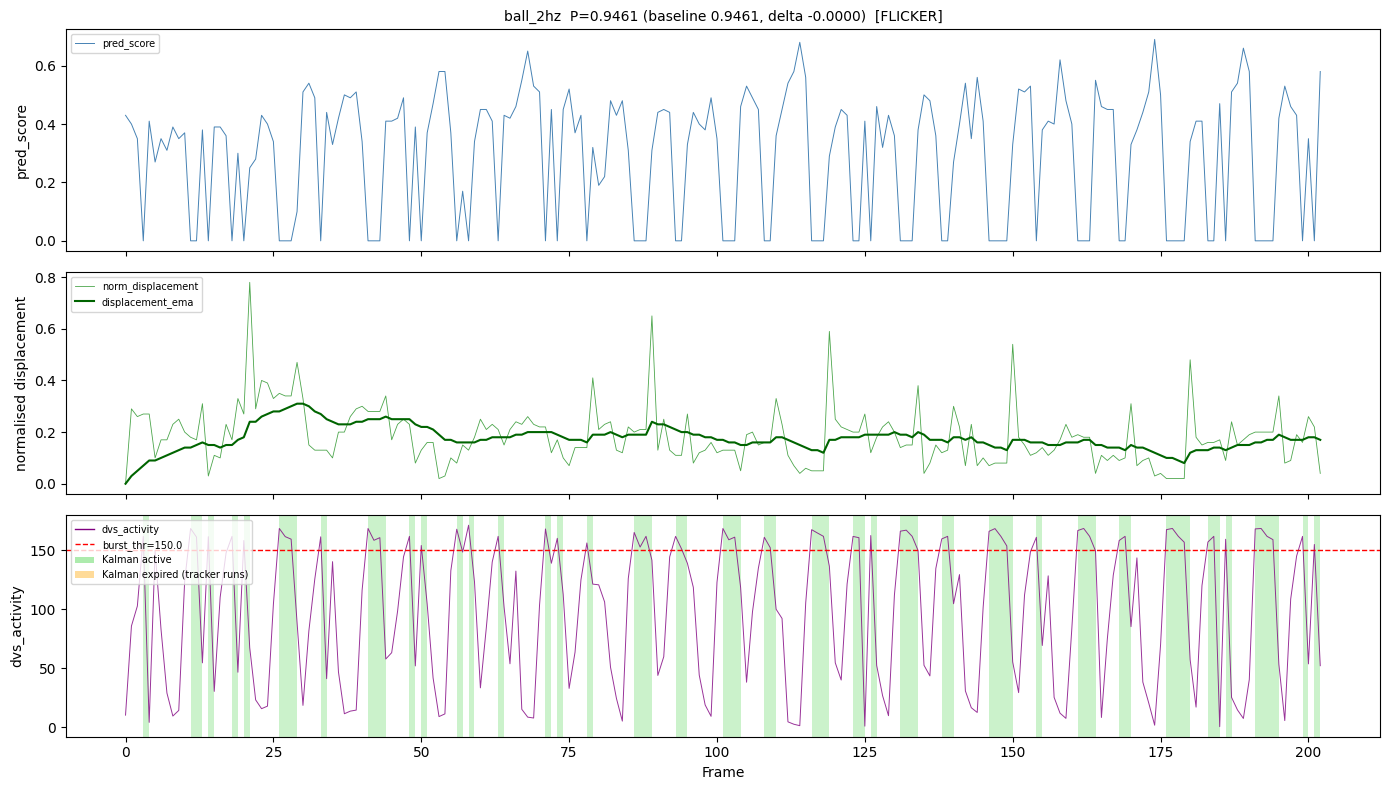

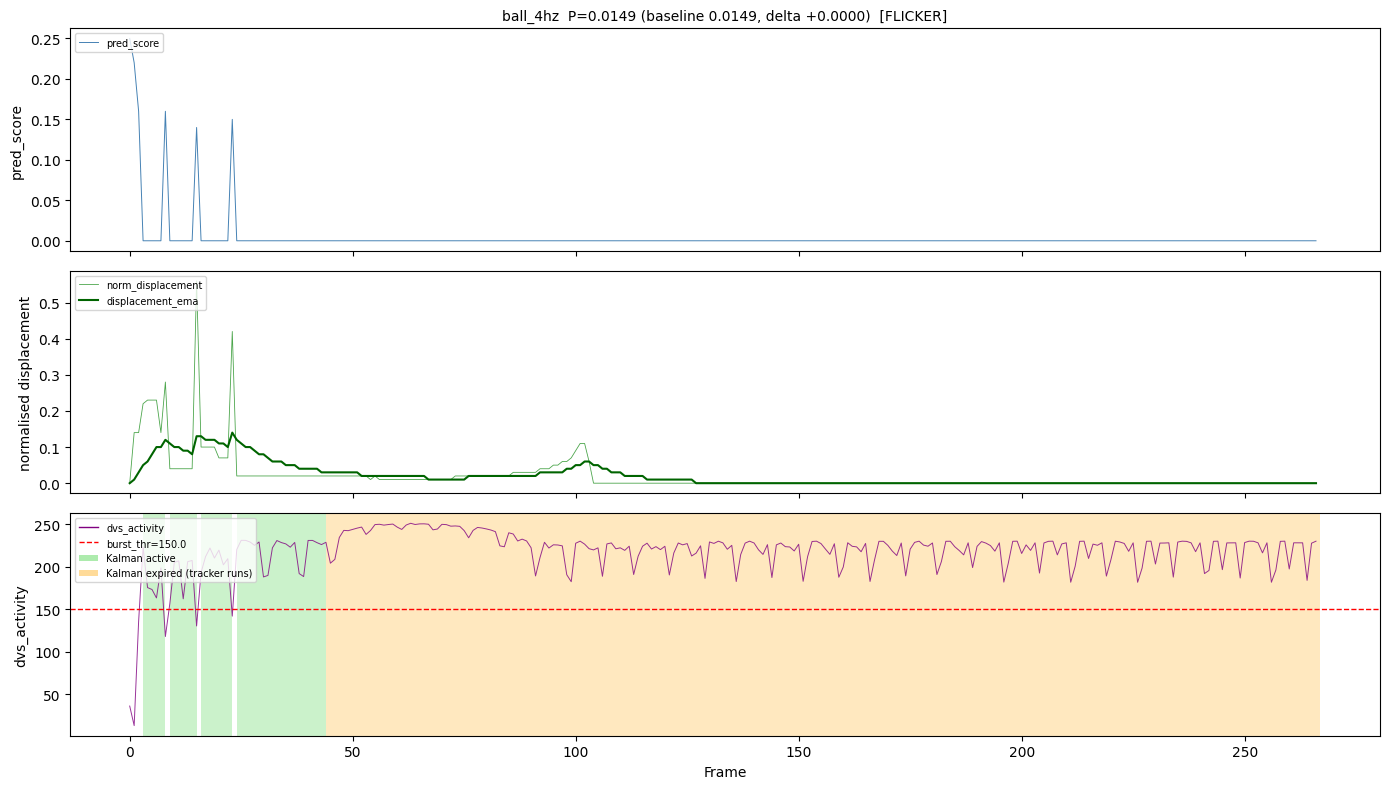

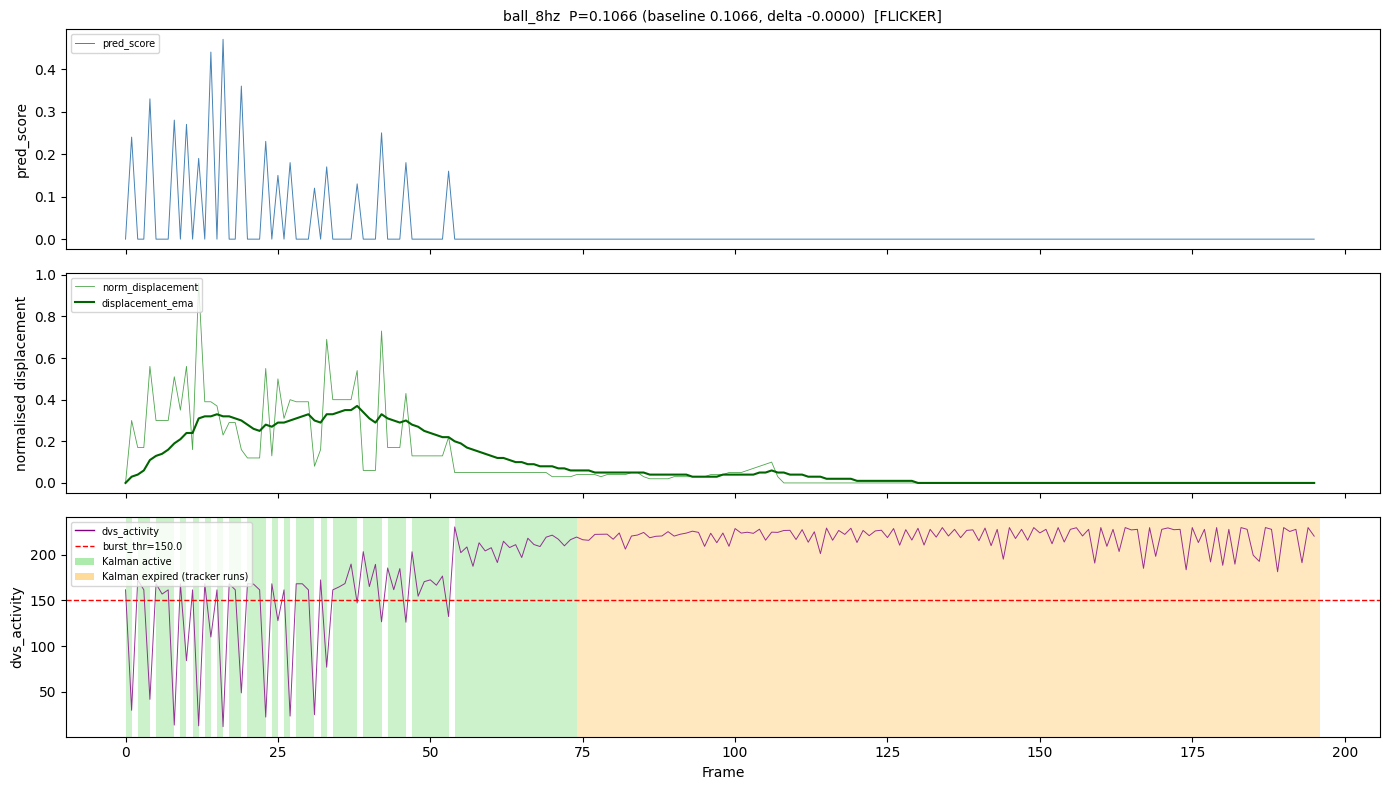

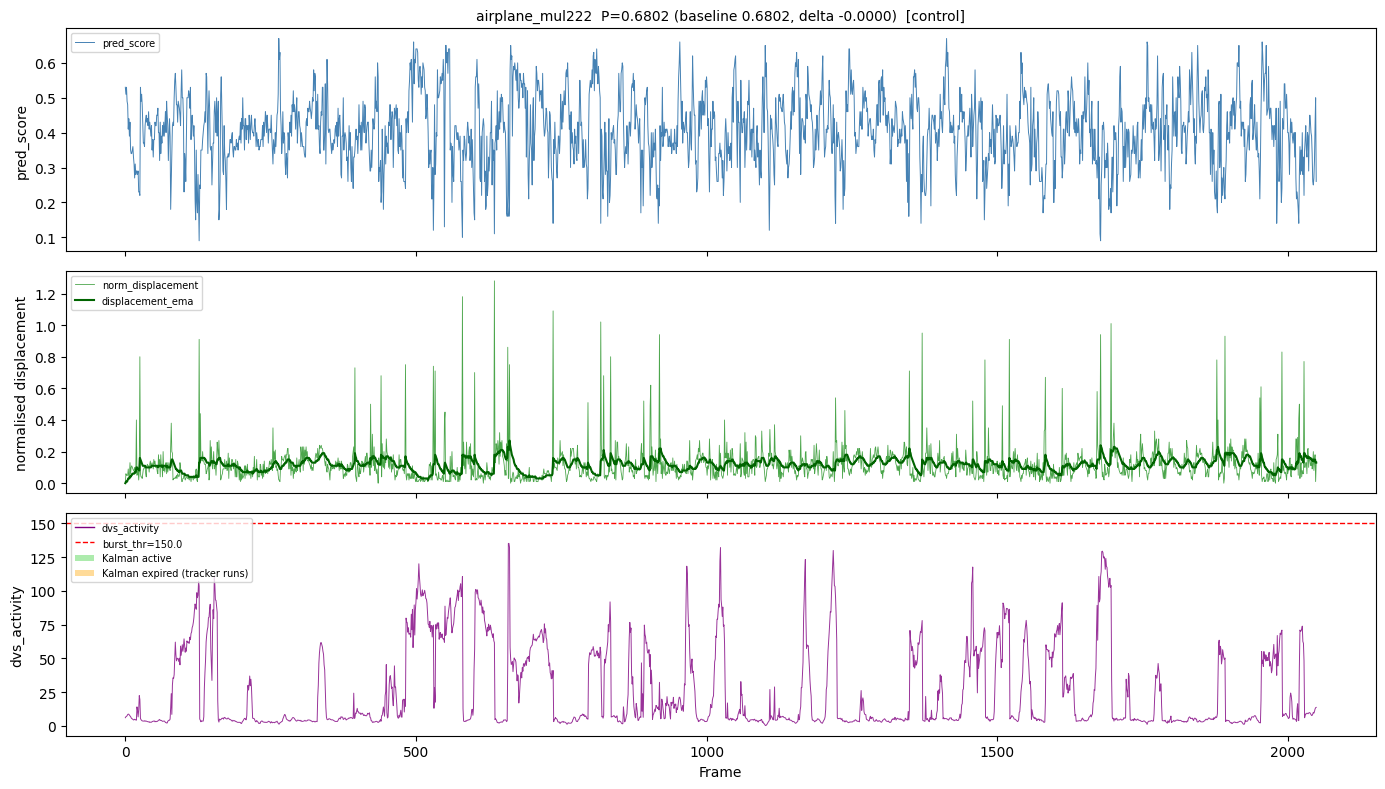

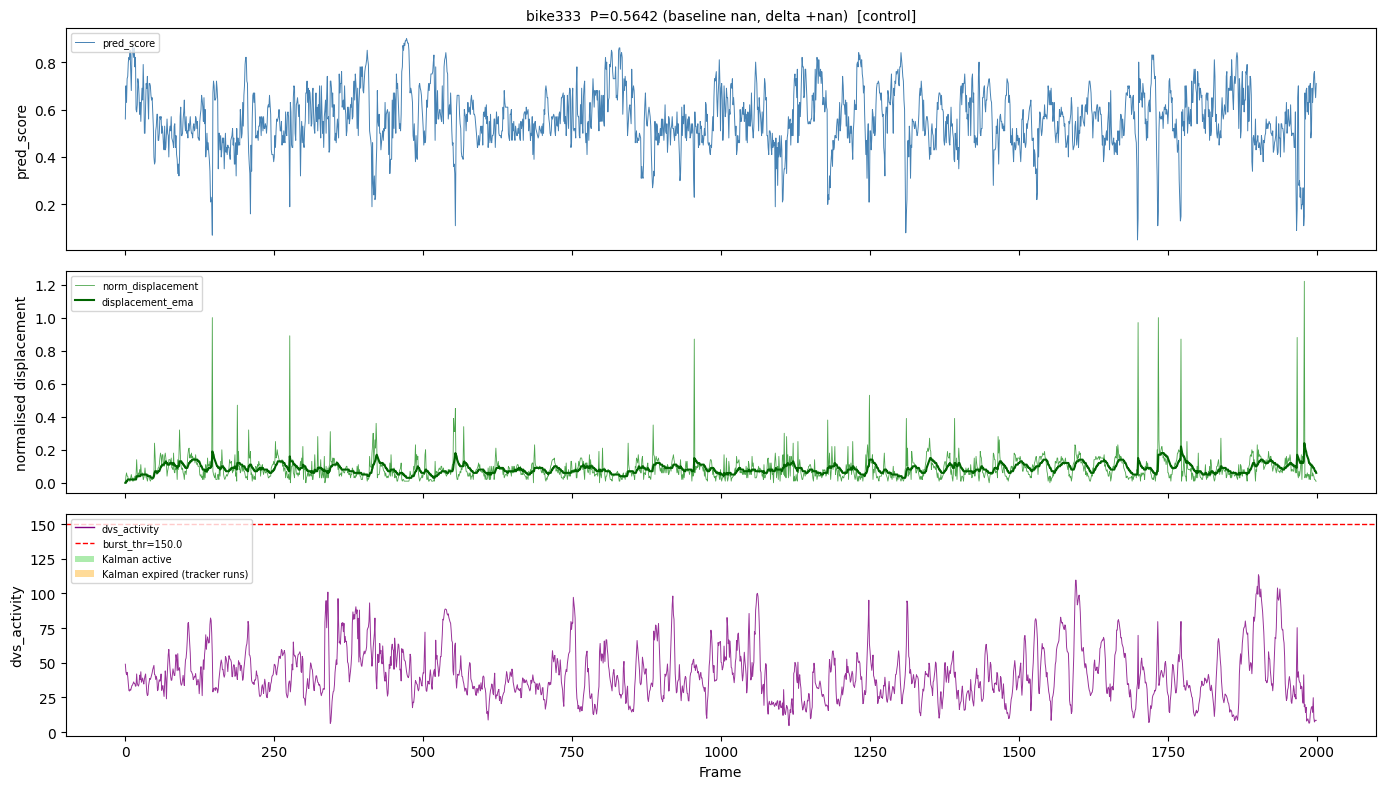

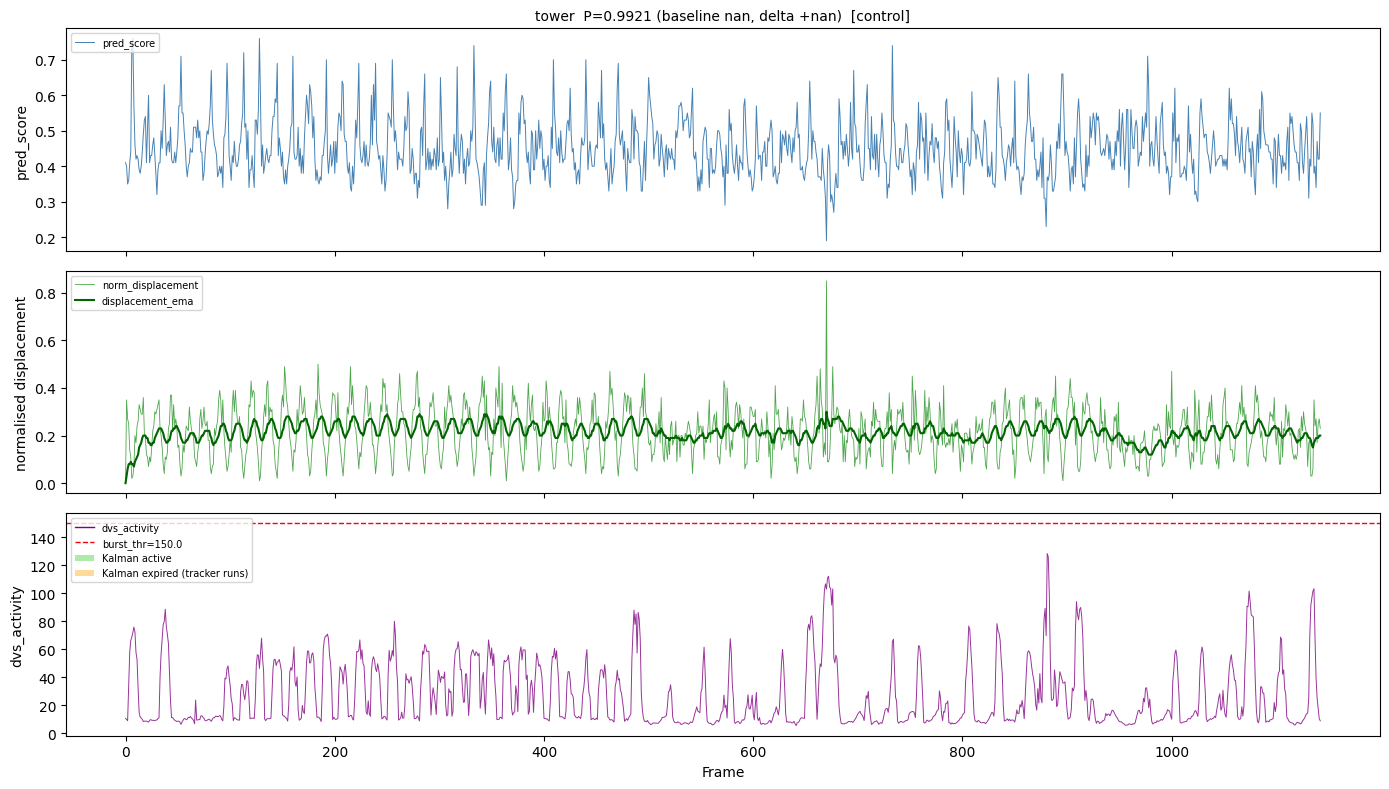

In [14]:
for seq in SEQUENCES:
    score     = load_sig(seq, 'pred_score')
    norm_disp = load_sig(seq, 'norm_displacement')
    disp_ema  = load_sig(seq, 'displacement_ema')
    dvs_act   = load_sig(seq, 'dvs_activity')
    burst_det = load_sig(seq, 'burst_detected')
    bfc       = load_sig(seq, 'burst_frame_count')
    if score is None:
        print(f'[MISSING] {seq}'); continue

    prec  = results[seq]['precision'] if seq in results else float('nan')
    base  = BASELINE.get(seq, float('nan'))
    label = 'FLICKER' if seq in FLICKER_SEQUENCES else 'control'
    frames = np.arange(len(score))

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    # Panel 1: pred_score
    ax = axes[0]
    ax.plot(frames, score, lw=0.7, color='steelblue', label='pred_score')
    ax.set_ylabel('pred_score')
    ax.legend(loc='upper left', fontsize=7)
    ax.set_title(f'{seq}  P={prec:.4f} (baseline {base:.4f}, delta {prec-base:+.4f})  [{label}]', fontsize=10)

    # Panel 2: displacement
    ax = axes[1]
    if norm_disp is not None:
        ax.plot(frames[:len(norm_disp)], norm_disp, lw=0.6, color='green', alpha=0.7, label='norm_displacement')
    if disp_ema is not None:
        ax.plot(frames[:len(disp_ema)], disp_ema, lw=1.5, color='darkgreen', label='displacement_ema')
    ax.set_ylabel('normalised displacement')
    ax.legend(loc='upper left', fontsize=7)

    # Panel 3: dvs_activity + Kalman-active shading
    ax = axes[2]
    if dvs_act is not None:
        ax.plot(frames[:len(dvs_act)], dvs_act, lw=0.7, color='purple', alpha=0.8, label='dvs_activity')
        ax.axhline(DVS_BURST_THRESHOLD, color='red', ls='--', lw=1, label=f'burst_thr={DVS_BURST_THRESHOLD}')
    # shade Kalman-active frames green, expired frames orange
    if burst_det is not None and bfc is not None:
        for fi in range(min(len(burst_det), len(frames))):
            if burst_det[fi] > 0:
                color = 'limegreen' if bfc[fi] <= KALMAN_MAX_BLIND else 'orange'
                ax.axvspan(fi, fi+1, alpha=0.25, color=color, linewidth=0)
    # legend patches
    from matplotlib.patches import Patch
    ax.legend(handles=[
        plt.Line2D([0],[0], color='purple', lw=1, label='dvs_activity'),
        plt.Line2D([0],[0], color='red', ls='--', lw=1, label=f'burst_thr={DVS_BURST_THRESHOLD}'),
        Patch(facecolor='limegreen', alpha=0.4, label='Kalman active'),
        Patch(facecolor='orange', alpha=0.4, label='Kalman expired (tracker runs)'),
    ], loc='upper left', fontsize=7)
    ax.set_ylabel('dvs_activity')
    ax.set_xlabel('Frame')

    plt.tight_layout()
    plt.show()

## Visualisation

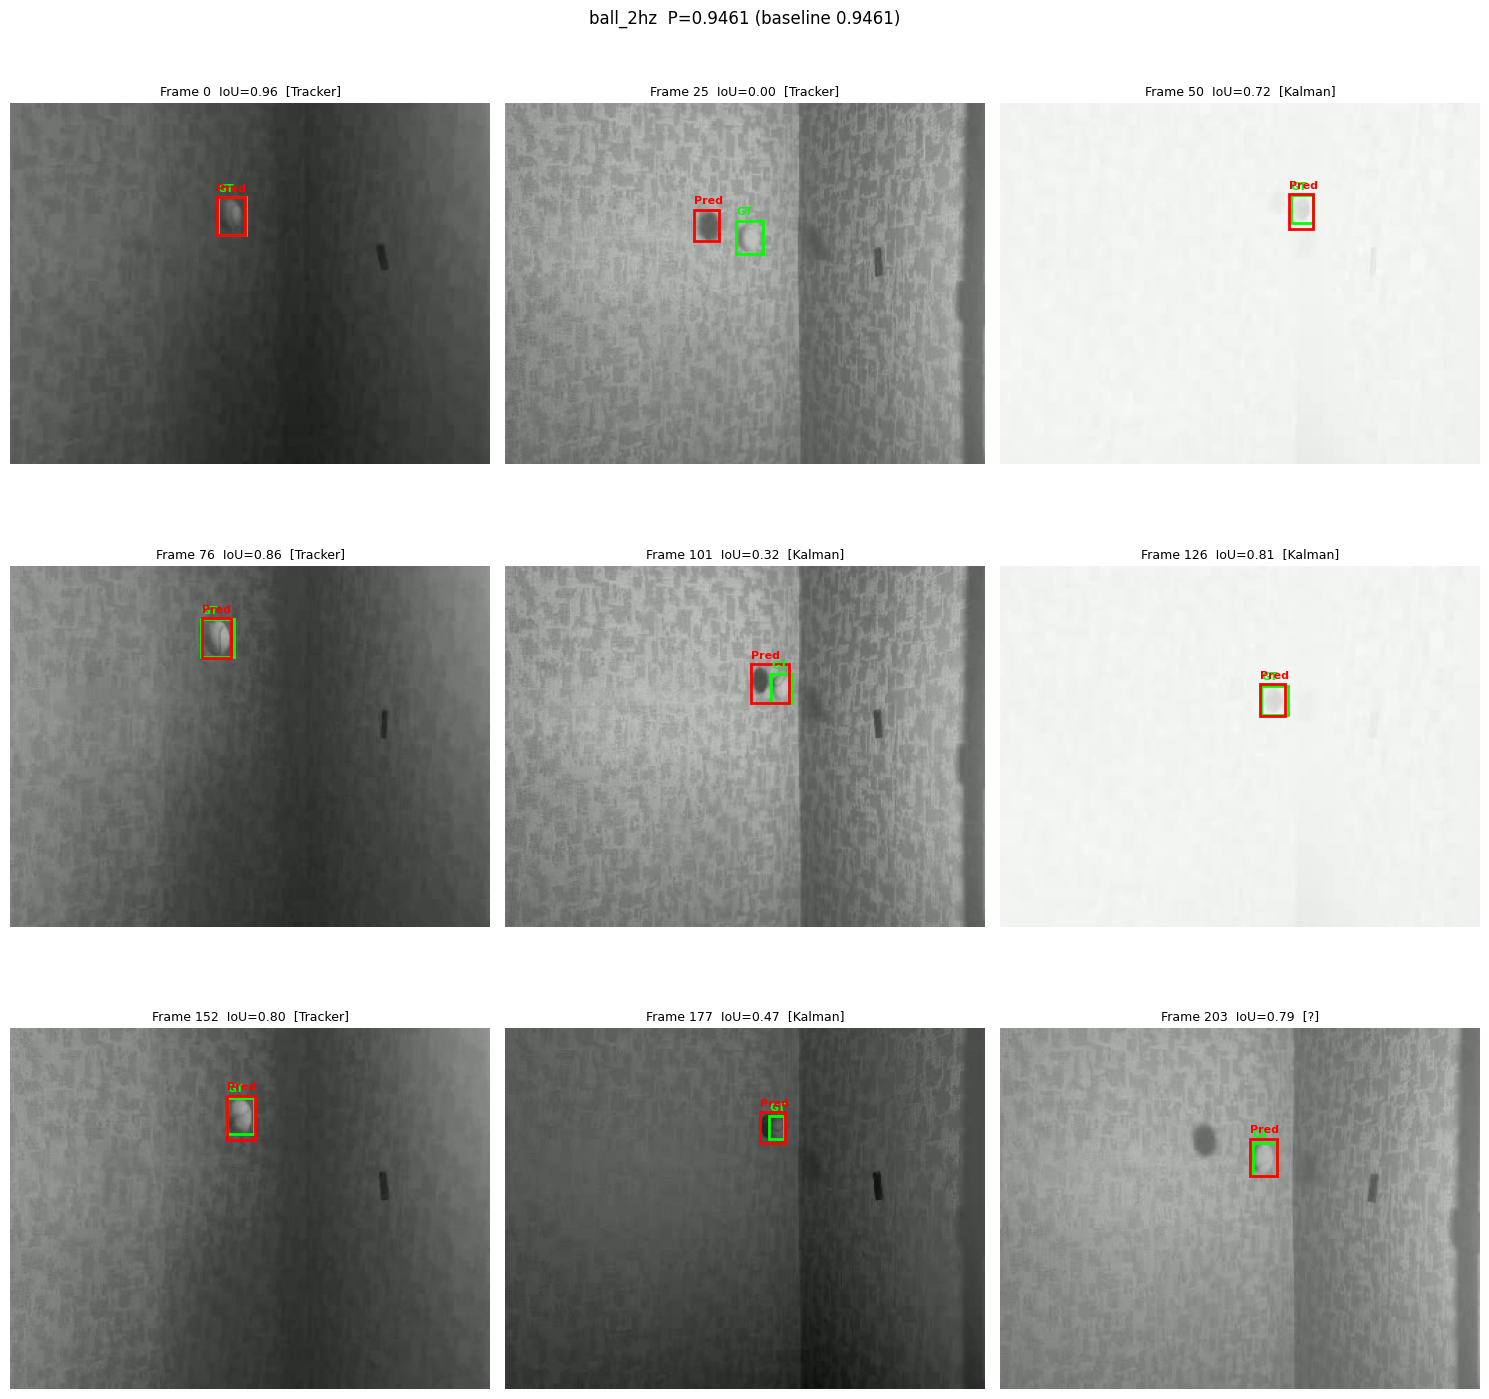

In [15]:
VIS_SEQ    = FLICKER_SEQUENCES[0]  # change to any sequence
VIS_FRAMES = 9

if VIS_SEQ not in results:
    print('Run the Metrics cell first.')
else:
    r   = results[VIS_SEQ]
    gt  = r['gt']; pr = r['pr']; iou = r['iou']
    aps_dir     = os.path.join(SEQ_DATA_ROOT[VIS_SEQ], VIS_SEQ, 'aps')
    frame_files = sorted([f for f in os.listdir(aps_dir) if f.lower().endswith(('.jpg', '.png'))])
    total   = min(len(frame_files), len(gt), len(pr))
    indices = np.linspace(0, total-1, VIS_FRAMES, dtype=int)

    burst_det = load_sig(VIS_SEQ, 'burst_detected')
    bfc       = load_sig(VIS_SEQ, 'burst_frame_count')

    cols = 3; rows = (VIS_FRAMES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten()
    for plot_i, frame_i in enumerate(indices):
        img = cv2.cvtColor(cv2.imread(os.path.join(aps_dir, frame_files[frame_i])), cv2.COLOR_BGR2RGB)
        ax = axes[plot_i]
        ax.imshow(img)
        for box, color, lbl in [(gt[frame_i],'lime','GT'), (pr[frame_i],'red','Pred')]:
            x, y, w, h = box
            ax.add_patch(patches.Rectangle((x,y),w,h, linewidth=2, edgecolor=color, facecolor='none'))
            ax.text(x, y-4, lbl, color=color, fontsize=8, fontweight='bold')
        # indicate Kalman state
        if burst_det is not None and frame_i < len(burst_det):
            if burst_det[frame_i] > 0:
                state = 'Kalman' if bfc[frame_i] <= KALMAN_MAX_BLIND else 'Tracker(burst)'
                ax.set_facecolor('#ffe0e0' if 'Tracker' in state else '#e0ffe0')
            else:
                state = 'Tracker'
        else:
            state = '?'
        ax.set_title(f'Frame {frame_i}  IoU={iou[frame_i]:.2f}  [{state}]', fontsize=9)
        ax.axis('off')
    for ax in axes[VIS_FRAMES:]: ax.axis('off')
    plt.suptitle(f'{VIS_SEQ}  P={results[VIS_SEQ]["precision"]:.4f} (baseline {BASELINE.get(VIS_SEQ,0):.4f})', fontsize=12)
    plt.tight_layout()
    plt.show()

In [18]:
results = {}
print(f'  {"Sequence":<18} {"P@20px":>8} {"S@0.5":>7}')
print('  ' + '─'*35)
for seq in SEQUENCES:
    gt_path = os.path.join(SEQ_DATA_ROOT[seq], seq, 'groundtruth_rect.txt')
    pr_path = os.path.join(RESULTS_DIR, f'{seq}.txt')
    if not os.path.isfile(pr_path):
        print(f'  [MISSING] {seq}'); continue
    gt = np.loadtxt(gt_path, delimiter=',')
    pr = np.loadtxt(pr_path)
    prec, succ, dist, iou = calc_metrics(gt, pr)
    results[seq] = dict(precision=prec, success=succ, dist=dist, iou=iou, gt=gt, pr=pr)
    label = 'FLICKER' if seq in FLICKER_SEQUENCES else 'control'
    print(f'  [{label}] {seq:<18} {prec:>8.4f}  S={succ:.4f}')

  Sequence             P@20px   S@0.5
  ───────────────────────────────────
  [FLICKER] ball_2hz             0.9461  S=0.6569
  [FLICKER] ball_4hz             0.0149  S=0.0037
  [FLICKER] ball_8hz             0.1066  S=0.0508
  [control] airplane_mul222      0.6802  S=0.3720
  [control] bike333              0.5642  S=0.4553
  [control] tower                0.9921  S=0.8802
